# Breast Cancer Wisconsin - ML Classification Project

**Course:** CS-UY 4563 – Introduction to Machine Learning  
**Team Members:**
- Saad Iftikhar
- Ahmed Arkam Mohamed Faisaar

---

## Project Overview

**Dataset:** Breast Cancer Wisconsin from UCI ML Repository  
**Task:** Binary classification
**Samples:** 569 instances  
**Features:** 30 real-valued features describing cell nuclei properties  

**Objective:** Train and evaluate 72 machine learning models (3 algorithms × 4 feature spaces × 6 hyperparameters) to predict breast tumor malignancy with high accuracy.

---

## Import Libraries and Setup

We begin by importing all necessary libraries for:
- Data manipulation (NumPy, Pandas)
- Visualization (Matplotlib, Seaborn)
- Machine learning (scikit-learn)
- Model evaluation

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           adjusted_rand_score, normalized_mutual_info_score)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("BREAST CANCER WISCONSIN (DIAGNOSTIC) - ML PROJECT")
print("="*80)
print("✓ All libraries imported successfully!")

BREAST CANCER WISCONSIN (DIAGNOSTIC) - ML PROJECT
✓ All libraries imported successfully!


---

# A. Data Loading

We load the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository.

**Dataset Information:**
- **Source:** UCI ML Repository
- **Samples:** 569 tumor instances
- **Features:** 30 real-valued measurements
- **Target:** Binary classification (0=Benign, 1=Malignant)
- **Missing Values:** None

The dataset will automatically fallback to scikit-learn's version if the UCI repository package is not available.

In [ ]:
# Load dataset
try:
    from ucimlrepo import fetch_ucirepo
    breast_cancer = fetch_ucirepo(id=17)
    X = breast_cancer.data.features
    y = breast_cancer.data.targets
    print("✓ Dataset loaded successfully using ucimlrepo")
except:
    print("⚠ ucimlrepo not available, loading from sklearn...")
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.DataFrame(data.target, columns=['Diagnosis'])
    # Convert to match UCI format: 0=benign, 1=malignant
    y['Diagnosis'] = 1 - y['Diagnosis']

# Convert target to binary format
if y.iloc[:, 0].dtype == 'object':
    y_binary = (y.iloc[:, 0] == 'M').astype(int)
else:
    y_binary = y.iloc[:, 0]

⚠ ucimlrepo not available, loading from sklearn...


### Dataset Summary Statistics

In [ ]:
# Display dataset information
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nClass distribution:")
print(f"  Benign (0): {(y_binary == 0).sum()} ({(y_binary == 0).sum() / len(y_binary) * 100:.1f}%)")
print(f"  Malignant (1): {(y_binary == 1).sum()} ({(y_binary == 1).sum() / len(y_binary) * 100:.1f}%)")

# Check for missing values
print(f"\nMissing values: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() == 0:
    print("✓ No missing values detected - dataset is complete!")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
display(X.head())

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569

Class distribution:
  Benign (0): 357 (62.7%)
  Malignant (1): 212 (37.3%)

Missing values: 0
✓ No missing values detected - dataset is complete!

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---

# B. Exploratory Data Analysis (EDA)

We perform comprehensive exploratory analysis to understand the dataset structure, feature distributions, and relationships.

**Analysis Steps:**
1. Basic statistical summary
2. Feature distributions by class (Benign vs Malignant)
3. Correlation analysis to identify multicollinearity
4. Feature importance ranking using ANOVA F-test

## B.1 Basic Statistical Summary

In [ ]:
# Display basic statistics
print("Statistical Summary of Features:")
display(X.describe())

Statistical Summary of Features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## B.2 Feature Distributions by Class

We visualize how key features differ between benign and malignant tumors.

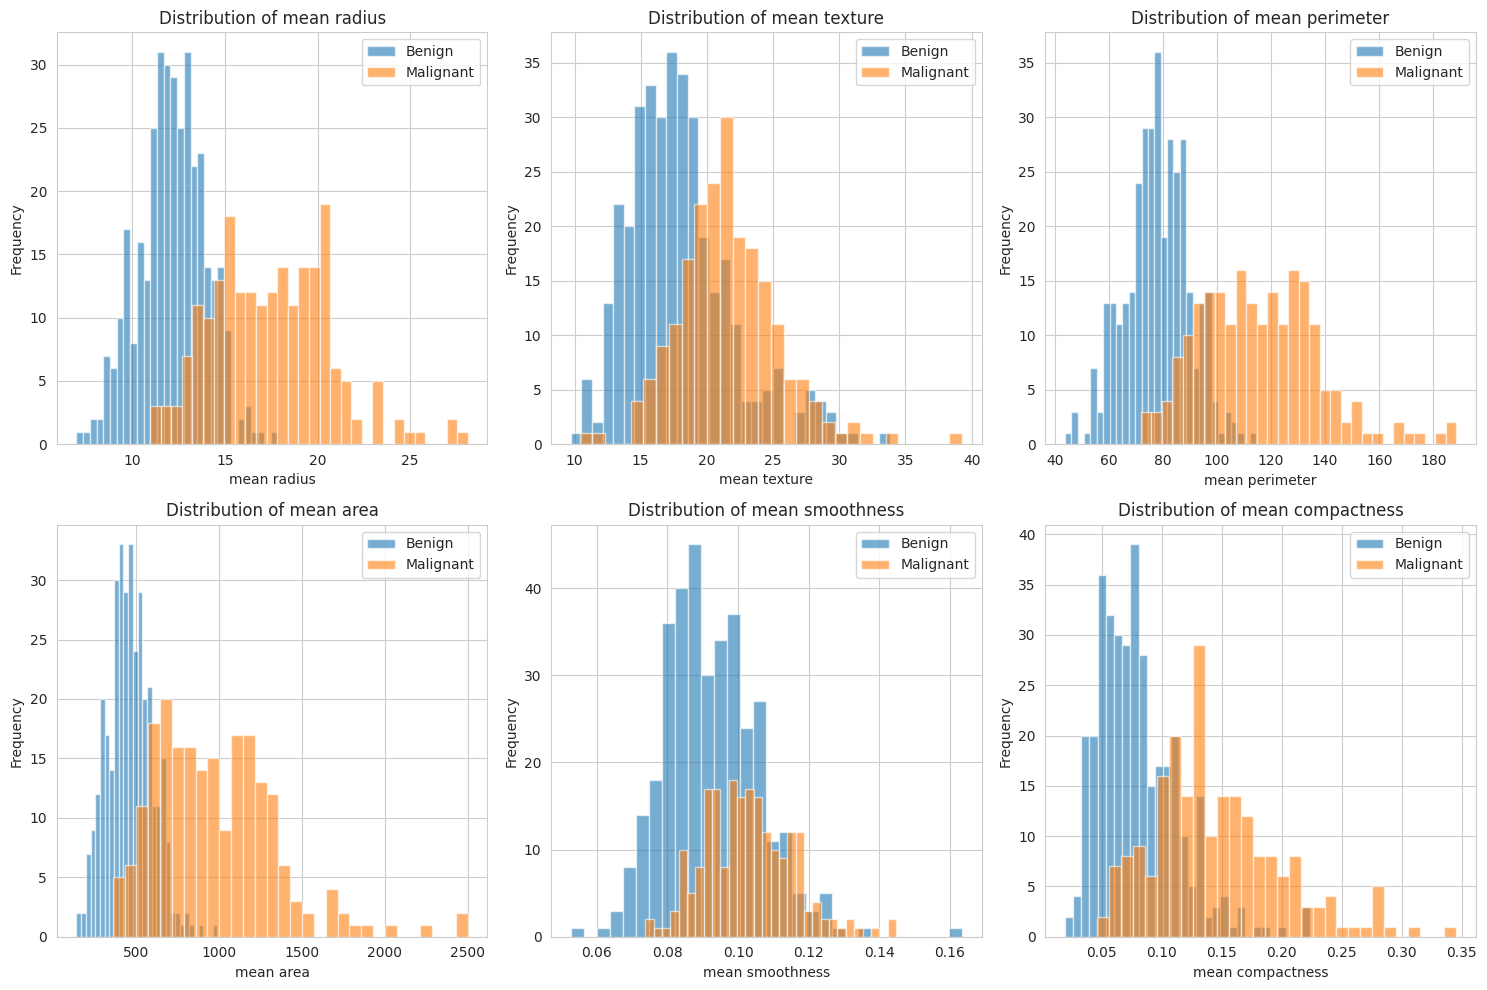

In [ ]:
# Create feature distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = X.columns[:6]  # First 6 features

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    for class_val, label in [(0, 'Benign'), (1, 'Malignant')]:
        X[y_binary == class_val][feature].hist(ax=ax, alpha=0.6, bins=30, label=label)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

## B.3 Correlation Matrix

We compute correlations between all features to identify potential multicollinearity.

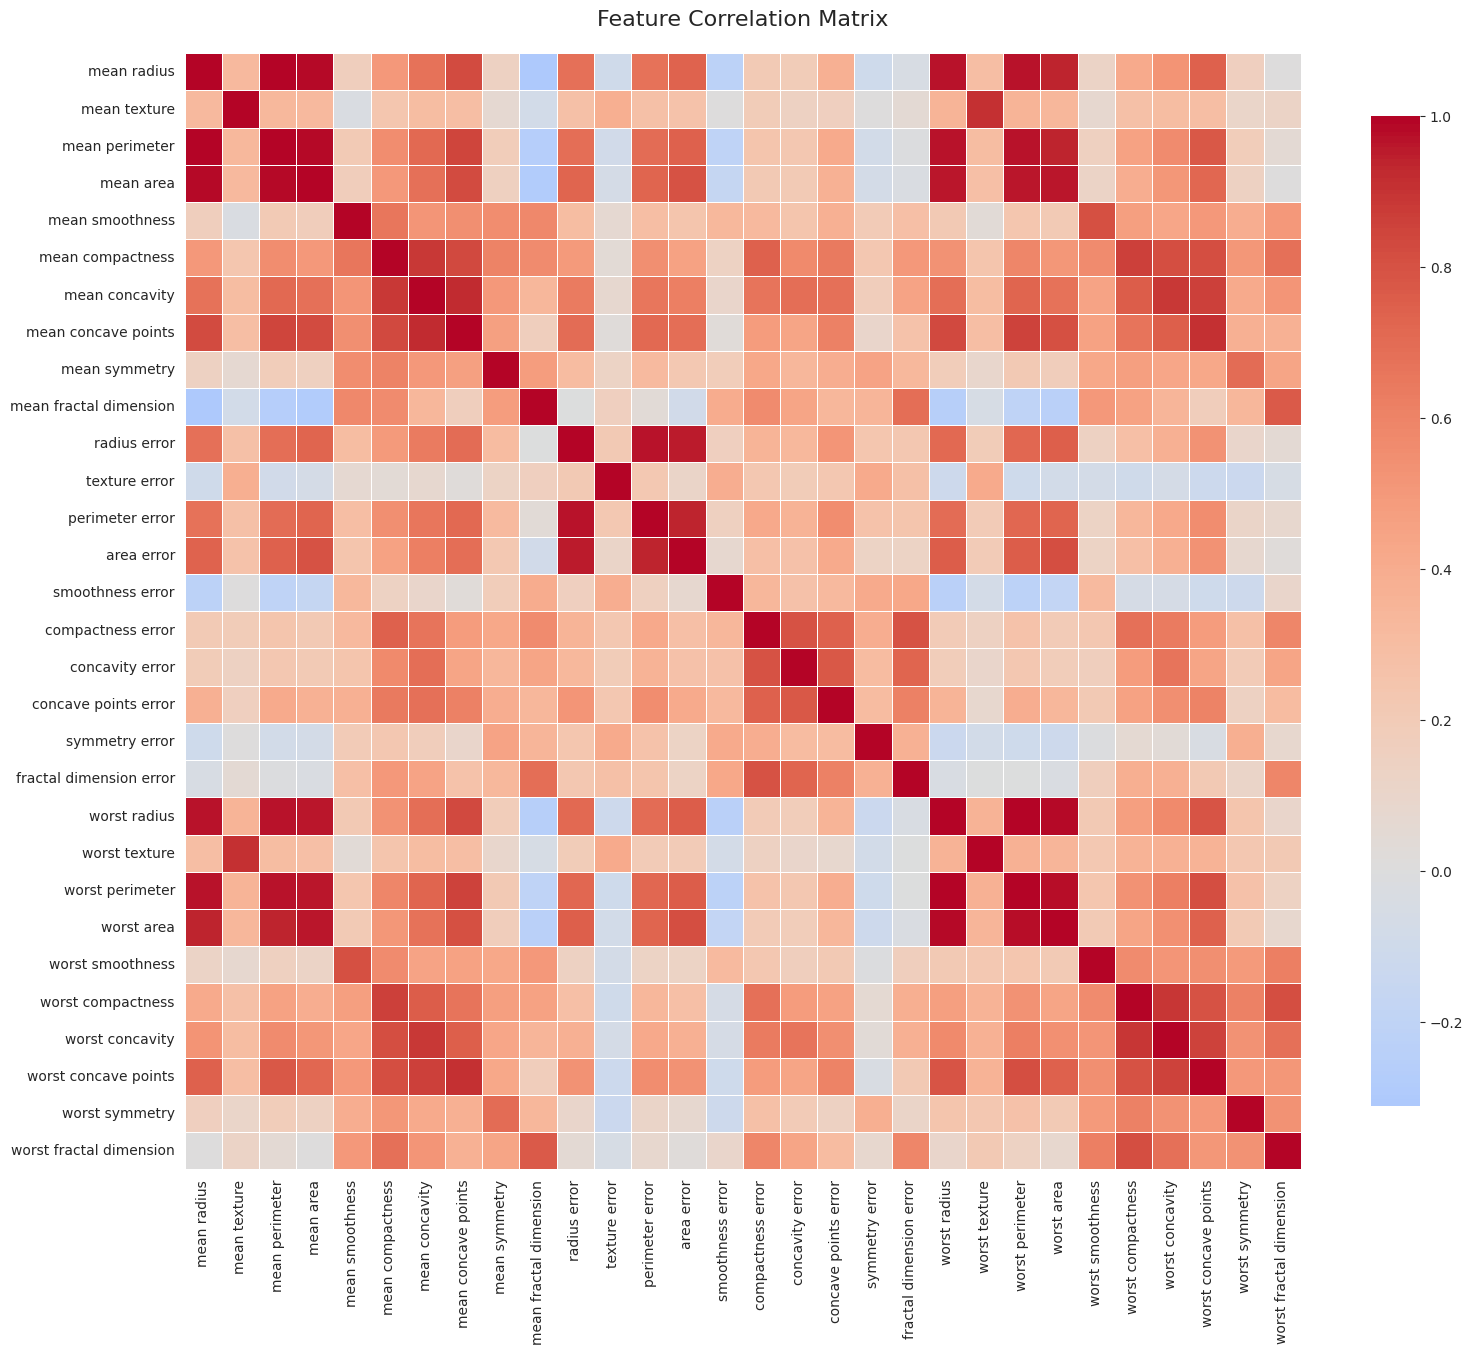


Highly correlated feature pairs (|r| > 0.9): 21

Top 5 pairs:
  mean radius ↔ mean perimeter: 0.998
  mean radius ↔ mean area: 0.987
  mean radius ↔ worst radius: 0.970
  mean radius ↔ worst perimeter: 0.965
  mean radius ↔ worst area: 0.941


In [ ]:
# Compute and visualize correlation matrix
plt.figure(figsize=(16, 14))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation_matrix.columns[i],
                                   correlation_matrix.columns[j],
                                   correlation_matrix.iloc[i, j]))

print(f"\nHighly correlated feature pairs (|r| > 0.9): {len(high_corr_pairs)}")
print("\nTop 5 pairs:")
for feat1, feat2, corr in high_corr_pairs[:5]:
    print(f"  {feat1} ↔ {feat2}: {corr:.3f}")

## B.4 Feature Importance Ranking

We use ANOVA F-test to rank features by their discriminative power.

Top 10 most important features:


,Feature,F-score
27,worst concave points,964.385393
22,worst perimeter,897.944219
7,mean concave points,861.676020
20,worst radius,860.781707
2,mean perimeter,697.235272
23,worst area,661.600206
0,mean radius,646.981021
3,mean area,573.060747
6,mean concavity,533.793126
26,worst concavity,436.691939


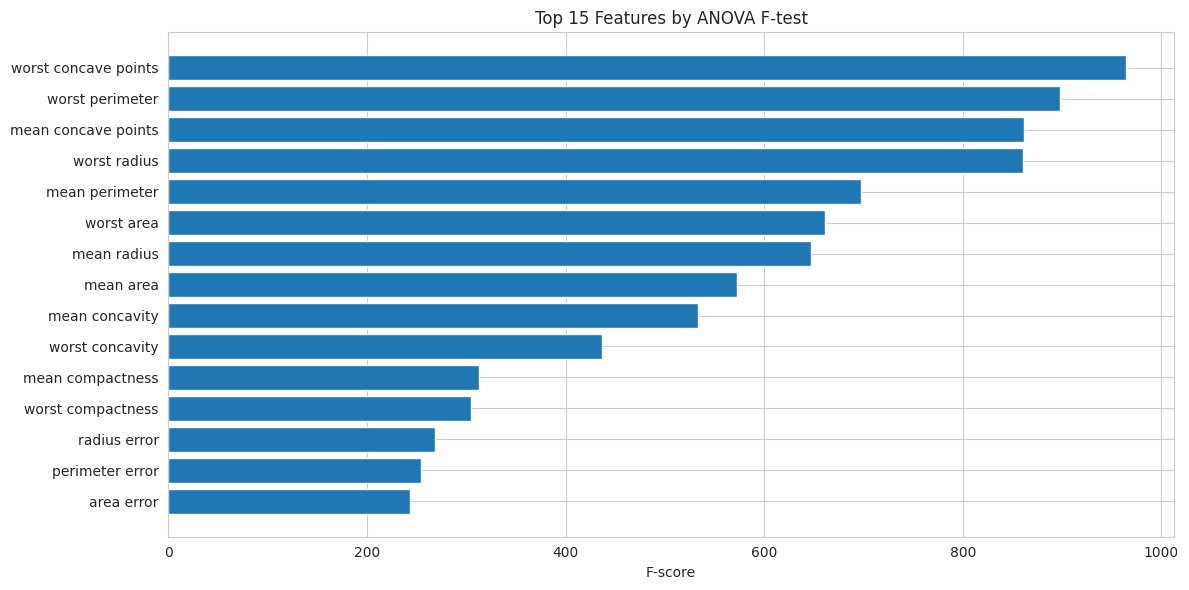

In [ ]:
# Feature importance using ANOVA F-test
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y_binary)
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-score': selector.scores_
}).sort_values('F-score', ascending=False)

print("Top 10 most important features:")
display(feature_scores.head(10))

# Visualize top 15 features
plt.figure(figsize=(12, 6))
top_features = feature_scores.head(15)
plt.barh(range(len(top_features)), top_features['F-score'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('F-score')
plt.title('Top 15 Features by ANOVA F-test')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---

# C. Data Preprocessing & Splitting

We prepare the data for machine learning:

**Steps:**
1. **Stratified Split:** 60% train / 20% validation / 20% test
2. **Feature Scaling:** StandardScaler (μ=0, σ=1)
3. **No Data Leakage:** Fit scaler on training set only

**Important:** Scaling is considered preprocessing, NOT a feature transformation for this project.

In [ ]:
# Stratified train/val/test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print("Dataset splits:")
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nClass distribution in splits:")
print(f"  Train - Benign: {(y_train == 0).sum()}, Malignant: {(y_train == 1).sum()}")
print(f"  Val   - Benign: {(y_val == 0).sum()}, Malignant: {(y_val == 1).sum()}")
print(f"  Test  - Benign: {(y_test == 0).sum()}, Malignant: {(y_test == 1).sum()}")

Dataset splits:
  Training set:   341 samples (59.9%)
  Validation set: 114 samples (20.0%)
  Test set:       114 samples (20.0%)

Class distribution in splits:
  Train - Benign: 214, Malignant: 127
  Val   - Benign: 71, Malignant: 43
  Test  - Benign: 72, Malignant: 42


In [ ]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled to zero mean and unit variance")
print(f"\nScaled training data shape: {X_train_scaled.shape}")

---

# D. Unsupervised Learning

We apply unsupervised methods to understand the data structure:

1. **Principal Component Analysis (PCA)** - Dimensionality reduction
2. **K-Means Clustering (k=2)** - Natural grouping discovery

## D.1 Principal Component Analysis (PCA)

PCA helps us:
- Reduce dimensionality while preserving variance
- Remove multicollinearity
- Visualize high-dimensional data in 2D

Number of components for 95% variance: 10
Explained variance by first 5 components: 85.22%


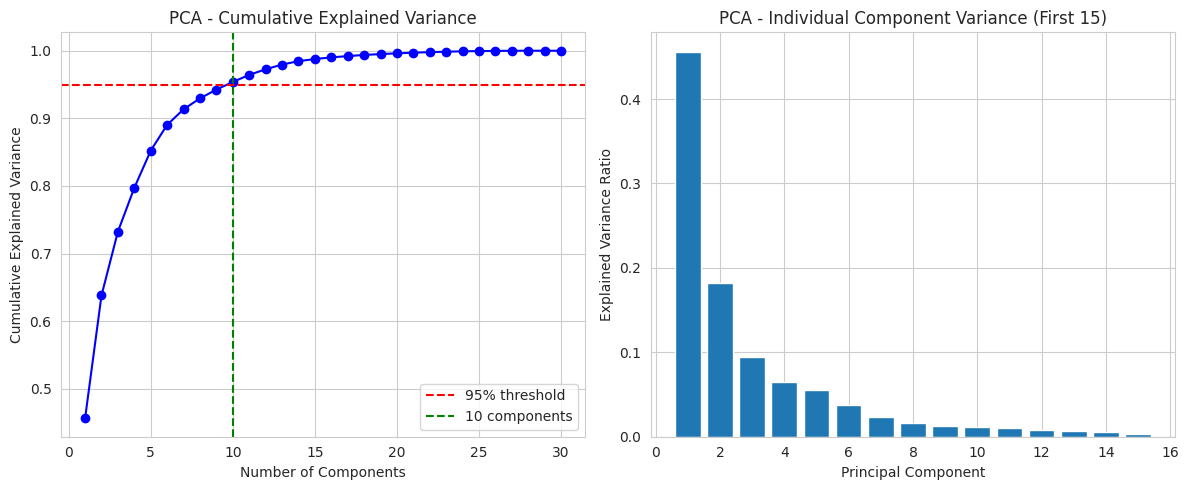

In [ ]:
# Fit PCA on training data
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Find number of components for 95% variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f"Number of components for 95% variance: {n_components_95}")
print(f"Explained variance by first 5 components: {cumsum_variance[4]:.2%}")

# Visualize explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, 16), pca_full.explained_variance_ratio_[:15])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Individual Component Variance (First 15)')
plt.grid(True)

plt.tight_layout()
plt.show()

### 2D PCA Visualization

Project data onto first two principal components to visualize class separability.

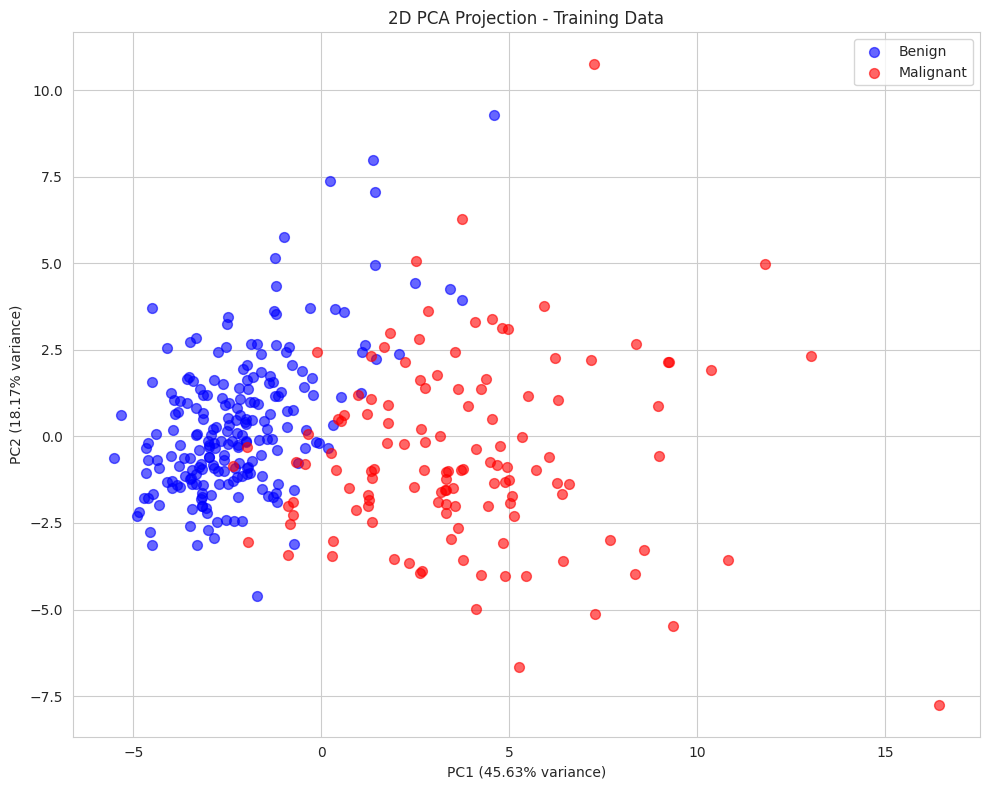

In [ ]:
# 2D PCA visualization
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
for class_val, label, color in [(0, 'Benign', 'blue'), (1, 'Malignant', 'red')]:
    mask = y_train.values == class_val
    plt.scatter(X_train_pca_2d[mask, 0], X_train_pca_2d[mask, 1],
               c=color, label=label, alpha=0.6, s=50)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('2D PCA Projection - Training Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Re-execute necessary data loading, splitting, and scaling steps to define X_train_scaled

# A. Data Loading (from cell PXzwpv67he83)
try:
    from ucimlrepo import fetch_ucirepo
    breast_cancer = fetch_ucirepo(id=17)
    X = breast_cancer.data.features
    y = breast_cancer.data.targets
    print("✓ Dataset loaded successfully using ucimlrepo")
except:
    print("⚠ ucimlrepo not available, loading from sklearn...")
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.DataFrame(data.target, columns=['Diagnosis'])
    # Convert to match UCI format: 0=benign, 1=malignant
    y['Diagnosis'] = 1 - y['Diagnosis']

# Convert target to binary format
if y.iloc[:, 0].dtype == 'object':
    y_binary = (y.iloc[:, 0] == 'M').astype(int)
else:
    y_binary = y.iloc[:, 0]

# C. Data Preprocessing & Splitting (from cell XRKgFzpRhe85)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

# Feature Scaling using StandardScaler (from cell zgE2og-ihe85)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled to zero mean and unit variance")

⚠ ucimlrepo not available, loading from sklearn...
✓ Features scaled to zero mean and unit variance


## D.2 K-Means Clustering (k=2)

Apply K-Means with 2 clusters to see if unsupervised clustering naturally discovers the tumor classes.

Adjusted Rand Index: 0.647
Normalized Mutual Information: 0.525

Cluster vs True Label Comparison:


Cluster,0,1
True Label,,
0,202,12
1,21,106


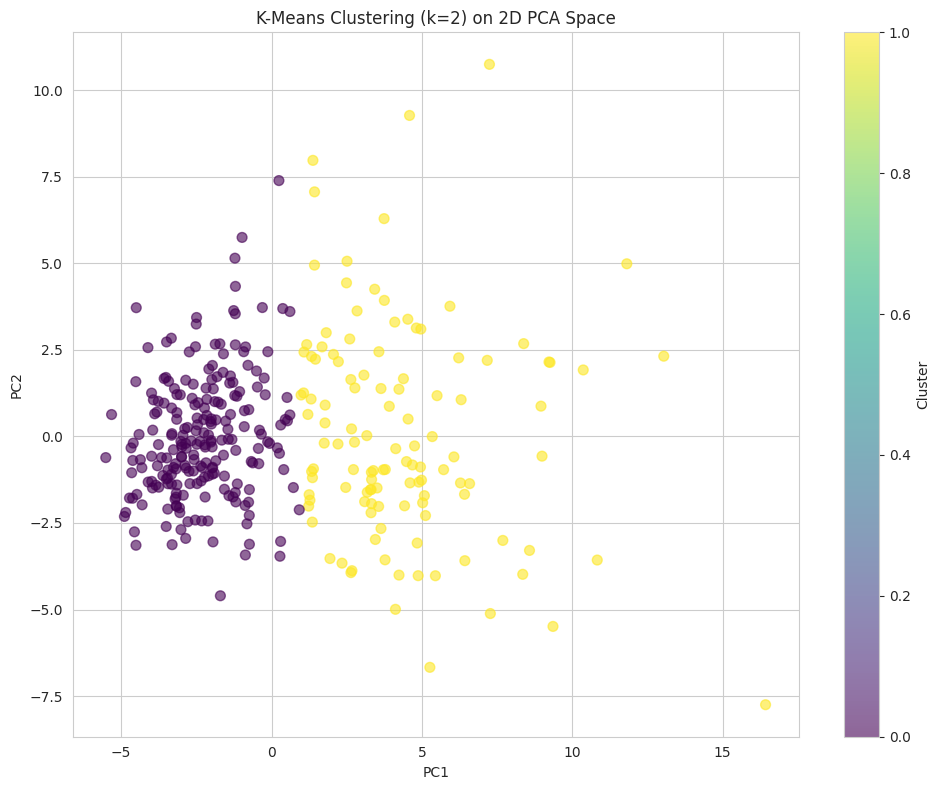

In [ ]:
# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Compare with true labels
ari = adjusted_rand_score(y_train, cluster_labels)
nmi = normalized_mutual_info_score(y_train, cluster_labels)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

# Confusion-style comparison
cluster_comparison = pd.crosstab(y_train, cluster_labels,
                                rownames=['True Label'],
                                colnames=['Cluster'])
print("\nCluster vs True Label Comparison:")
display(cluster_comparison)

# Visualize clusters on 2D PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1],
                     c=cluster_labels, cmap='viridis', alpha=0.6, s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (k=2) on 2D PCA Space')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

---

# E. Feature Transformations (Z-Spaces)

Beyond baseline scaling, we create **3 feature transformations** as required:

1. **Z1: PCA Features** - 10 components (95% variance)
2. **Z2: Polynomial Features** - Degree-2 expansion on top 8 features
3. **Z3: SelectKBest** - Top 10 features by F-statistic

Plus **baseline**: Raw scaled features

**Total:** 4 feature spaces for model training

## Z1: PCA Features

**Rationale:**
- Removes multicollinearity
- Reduces dimensionality (30 → 10 features)
- May improve generalization

In [ ]:
# Z1: PCA transformation
pca_transform = PCA(n_components=n_components_95)
X_train_z1 = pca_transform.fit_transform(X_train_scaled)
X_val_z1 = pca_transform.transform(X_val_scaled)
X_test_z1 = pca_transform.transform(X_test_scaled)
print(f"✓ PCA transformation: {X_train.shape[1]} → {X_train_z1.shape[1]} features")

✓ PCA transformation: 30 → 10 features


## Z2: Polynomial Features (Degree 2)

**Rationale:**
- Captures non-linear relationships
- Adds interaction terms between features
- Increases model complexity

In [ ]:
# Z2: Polynomial features on top 8 features
top_k_features = 8
top_feature_indices = feature_scores['Feature'].head(top_k_features).values
top_feature_idx = [list(X.columns).index(f) for f in top_feature_indices]

X_train_top = X_train_scaled[:, top_feature_idx]
X_val_top = X_val_scaled[:, top_feature_idx]
X_test_top = X_test_scaled[:, top_feature_idx]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_z2 = poly.fit_transform(X_train_top)
X_val_z2 = poly.transform(X_val_top)
X_test_z2 = poly.transform(X_test_top)
print(f"✓ Polynomial transformation: {top_k_features} → {X_train_z2.shape[1]} features (degree 2)")

✓ Polynomial transformation: 8 → 44 features (degree 2)


## Z3: SelectKBest Features

**Rationale:**
- Focuses on most discriminative features
- Reduces dimensionality while maintaining interpretability
- Removes noisy features

In [ ]:
# Z3: SelectKBest (k=10)
k_best = 10
selector_z3 = SelectKBest(f_classif, k=k_best)
X_train_z3 = selector_z3.fit_transform(X_train_scaled, y_train)
X_val_z3 = selector_z3.transform(X_val_scaled)
X_test_z3 = selector_z3.transform(X_test_scaled)
selected_features = X.columns[selector_z3.get_support()].tolist()
print(f"✓ SelectKBest transformation: {X_train.shape[1]} → {X_train_z3.shape[1]} features")
print(f"\nSelected features: {', '.join(selected_features)}")

✓ SelectKBest transformation: 30 → 10 features

Selected features: mean radius, mean perimeter, mean area, mean concavity, mean concave points, worst radius, worst perimeter, worst area, worst concavity, worst concave points


## Summary: All Feature Spaces Created

In [ ]:
# Store all feature transformations
feature_spaces = {
    'Raw': (X_train_scaled, X_val_scaled, X_test_scaled),
    'PCA': (X_train_z1, X_val_z1, X_test_z1),
    'Polynomial': (X_train_z2, X_val_z2, X_test_z2),
    'SelectKBest': (X_train_z3, X_val_z3, X_test_z3)
}

print(f"✓ Created {len(feature_spaces)} feature spaces:\n")
for space_name, (X_tr, _, _) in feature_spaces.items():
    print(f"  • {space_name:12s}: {X_tr.shape[1]} features")

✓ Created 4 feature spaces:

  • Raw         : 30 features
  • PCA         : 10 features
  • Polynomial  : 44 features
  • SelectKBest : 10 features


---

# F. Model Training & Evaluation (72 Models)

We train **3 model families × 4 feature spaces × 6 hyperparameters = 72 models**

## Model Families:

### 1. Logistic Regression
- **Hyperparameter:** C (inverse regularization strength)
- **Values:** {0.001, 0.01, 0.1, 1, 10, 100}
- **Effect:** Smaller C = stronger regularization

### 2. K-Nearest Neighbors (KNN)
- **Hyperparameter:** k (number of neighbors)
- **Values:** {1, 3, 5, 7, 9, 15}
- **Effect:** Smaller k = more complex boundary

### 3. Multi-Layer Perceptron (MLP)
- **Architecture:** 1 hidden layer with 16 units
- **Hyperparameter:** α (L2 penalty)
- **Values:** {0.0001, 0.001, 0.01, 0.1, 0.5, 1.0}
- **Effect:** Larger α = stronger regularization

In [ ]:
# Define hyperparameter grids
hyperparameters = {
    'Logistic Regression': {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    'KNN': {'n_neighbors': [1, 3, 5, 7, 9, 15]},
    'MLP': {'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]}
}

print("Training Configuration:")
print(f"  Model families: {len(hyperparameters)}")
print(f"  Feature spaces: {len(feature_spaces)}")
print(f"  Hyperparameters per model: 6")
print(f"  Total models: {len(hyperparameters) * len(feature_spaces) * 6}")
print("\nStarting model training...")

Training Configuration:
  Model families: 3
  Feature spaces: 4
  Hyperparameters per model: 6
  Total models: 72

Starting model training...


In [ ]:
# Initialize results storage
results = []
model_counter = 0
total_models = 72

# Training loop
for model_name in ['Logistic Regression', 'KNN', 'MLP']:
    for space_name, (X_tr, X_v, X_te) in feature_spaces.items():

        hyperparam_name = list(hyperparameters[model_name].keys())[0]
        hyperparam_values = hyperparameters[model_name][hyperparam_name]

        for hyperparam_value in hyperparam_values:
            model_counter += 1

            # Create model
            if model_name == 'Logistic Regression':
                model = LogisticRegression(C=hyperparam_value, max_iter=10000,
                                         random_state=RANDOM_STATE)
            elif model_name == 'KNN':
                model = KNeighborsClassifier(n_neighbors=hyperparam_value)
            else:  # MLP
                model = MLPClassifier(hidden_layer_sizes=(16,), alpha=hyperparam_value,
                                    max_iter=2000, random_state=RANDOM_STATE,
                                    early_stopping=True, validation_fraction=0.1)

            # Train
            model.fit(X_tr, y_train)

            # Predict
            y_train_pred = model.predict(X_tr)
            y_val_pred = model.predict(X_v)

            # Metrics
            train_acc = accuracy_score(y_train, y_train_pred)
            val_acc = accuracy_score(y_val, y_val_pred)
            val_prec = precision_score(y_val, y_val_pred, zero_division=0)
            val_rec = recall_score(y_val, y_val_pred, zero_division=0)
            val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

            # Store results
            results.append({
                'Model': model_name,
                'Feature_Space': space_name,
                'Hyperparameter': hyperparam_name,
                'Hyperparam_Value': hyperparam_value,
                'Train_Accuracy': train_acc,
                'Val_Accuracy': val_acc,
                'Val_Precision': val_prec,
                'Val_Recall': val_rec,
                'Val_F1': val_f1,
                'Overfit_Gap': train_acc - val_acc
            })

            if model_counter % 12 == 0:
                print(f"  Progress: {model_counter}/{total_models} models trained ({model_counter/total_models*100:.0f}%)")

print(f"\n✓ All {total_models} models trained successfully!")

# Create results DataFrame
results_df = pd.DataFrame(results)

  Progress: 12/72 models trained (17%)
  Progress: 24/72 models trained (33%)
  Progress: 36/72 models trained (50%)
  Progress: 48/72 models trained (67%)
  Progress: 60/72 models trained (83%)
  Progress: 72/72 models trained (100%)

✓ All 72 models trained successfully!


---

# G. Results Analysis

Analyze performance of all 72 models to identify best configurations.

## Best Overall Model

In [ ]:
# Find best overall model
best_overall = results_df.loc[results_df['Val_F1'].idxmax()]
print("="*60)
print("BEST OVERALL MODEL")
print("="*60)
print(f"Model: {best_overall['Model']}")
print(f"Feature Space: {best_overall['Feature_Space']}")
print(f"{best_overall['Hyperparameter']}: {best_overall['Hyperparam_Value']}")
print(f"\nValidation Metrics:")
print(f"  Accuracy:  {best_overall['Val_Accuracy']:.4f}")
print(f"  F1-Score:  {best_overall['Val_F1']:.4f}")
print(f"  Precision: {best_overall['Val_Precision']:.4f}")
print(f"  Recall:    {best_overall['Val_Recall']:.4f}")
print(f"\nOverfitting Gap: {best_overall['Overfit_Gap']:.4f}")

BEST OVERALL MODEL
Model: Logistic Regression
Feature Space: Raw
C: 0.1

Validation Metrics:
  Accuracy:  0.9825
  F1-Score:  0.9762
  Precision: 1.0000
  Recall:    0.9535

Overfitting Gap: -0.0030


## Best Model per Family

In [ ]:
# Best per model family
print("Best Model per Family:\n")
for model_name in ['Logistic Regression', 'KNN', 'MLP']:
    best_model = results_df[results_df['Model'] == model_name].loc[
        results_df[results_df['Model'] == model_name]['Val_F1'].idxmax()
    ]
    print(f"{model_name}:")
    print(f"  Feature Space: {best_model['Feature_Space']}")
    print(f"  {best_model['Hyperparameter']}: {best_model['Hyperparam_Value']}")
    print(f"  Val F1: {best_model['Val_F1']:.4f}, Val Acc: {best_model['Val_Accuracy']:.4f}")
    print()

Best Model per Family:

Logistic Regression:
  Feature Space: Raw
  C: 0.1
  Val F1: 0.9762, Val Acc: 0.9825

KNN:
  Feature Space: Raw
  n_neighbors: 5.0
  Val F1: 0.9639, Val Acc: 0.9737

MLP:
  Feature Space: Polynomial
  alpha: 0.0001
  Val F1: 0.8571, Val Acc: 0.8947



## Summary Statistics

In [ ]:
# Summary statistics
print("Performance Summary Statistics:")
summary = results_df.groupby(['Model', 'Feature_Space']).agg({
    'Val_Accuracy': ['mean', 'std', 'max'],
    'Val_F1': ['mean', 'std', 'max']
}).round(4)
display(summary)

Performance Summary Statistics:


Val_Accuracy                  Val_F1  \
                                          mean     std     max    mean   
Model               Feature_Space                                        
KNN                 PCA                 0.9708  0.0045  0.9737  0.9604   
                    Polynomial          0.9415  0.0120  0.9649  0.9221   
                    Raw                 0.9678  0.0106  0.9737  0.9569   
                    SelectKBest         0.9357  0.0045  0.9386  0.9137   
Logistic Regression PCA                 0.9561  0.0266  0.9737  0.9394   
                    Polynomial          0.9254  0.0679  0.9649  0.8814   
                    Raw                 0.9576  0.0280  0.9825  0.9414   
                    SelectKBest         0.9444  0.0463  0.9737  0.9175   
MLP                 PCA                 0.8304  0.0045  0.8333  0.8014   
                    Polynomial          0.8947  0.0000  0.8947  0.8571   
                    Raw                 0.3772  0.0000  0.3772  0.5419   
                    SelectKBest         0.8596  0.0000  0.8596  0.8400   

                                                   
                                      std     max  
Model               Feature_Space                  
KNN                 PCA            0.0054  0.9639  
                    Polynomial     0.0151  0.9512  
                    Raw            0.0124  0.9639  
                    SelectKBest    0.0061  0.9176  
Logistic Regression PCA            0.0411  0.9655  
                    Polynomial     0.1332  0.9535  
                    Raw            0.0428  0.9762  
                    SelectKBest    0.0808  0.9647  
MLP                 PCA            0.0042  0.8041  
                    Polynomial     0.0000  0.8571  
                    Raw            0.0000  0.5419  
                    SelectKBest    0.0000  0.8400

## Top 10 Models by Validation F1-Score

In [ ]:
# Display top 10 models
top_10 = results_df.nlargest(10, 'Val_F1')[[
    'Model', 'Feature_Space', 'Hyperparameter', 'Hyperparam_Value',
    'Val_F1', 'Val_Accuracy', 'Val_Precision', 'Val_Recall'
]]
display(top_10)

,Model,Feature_Space,Hyperparameter,Hyperparam_Value,Val_F1,Val_Accuracy,Val_Precision,Val_Recall
2,Logistic Regression,Raw,C,0.1,0.976190,0.982456,1.000000,0.953488
3,Logistic Regression,Raw,C,1.0,0.965517,0.973684,0.954545,0.976744
9,Logistic Regression,PCA,C,1.0,0.965517,0.973684,0.954545,0.976744
21,Logistic Regression,SelectKBest,C,1.0,0.964706,0.973684,0.976190,0.953488
8,Logistic Regression,PCA,C,0.1,0.963855,0.973684,1.000000,0.930233
26,KNN,Raw,n_neighbors,5.0,0.963855,0.973684,1.000000,0.930233
27,KNN,Raw,n_neighbors,7.0,0.963855,0.973684,1.000000,0.930233
28,KNN,Raw,n_neighbors,9.0,0.963855,0.973684,1.000000,0.930233
29,KNN,Raw,n_neighbors,15.0,0.963855,0.973684,1.000000,0.930233
32,KNN,PCA,n_neighbors,5.0,0.963855,0.973684,1.000000,0.930233


---

# H. Results Visualizations

Create comprehensive plots to analyze model performance.

## H.1 Performance Comparison by Model and Feature Space

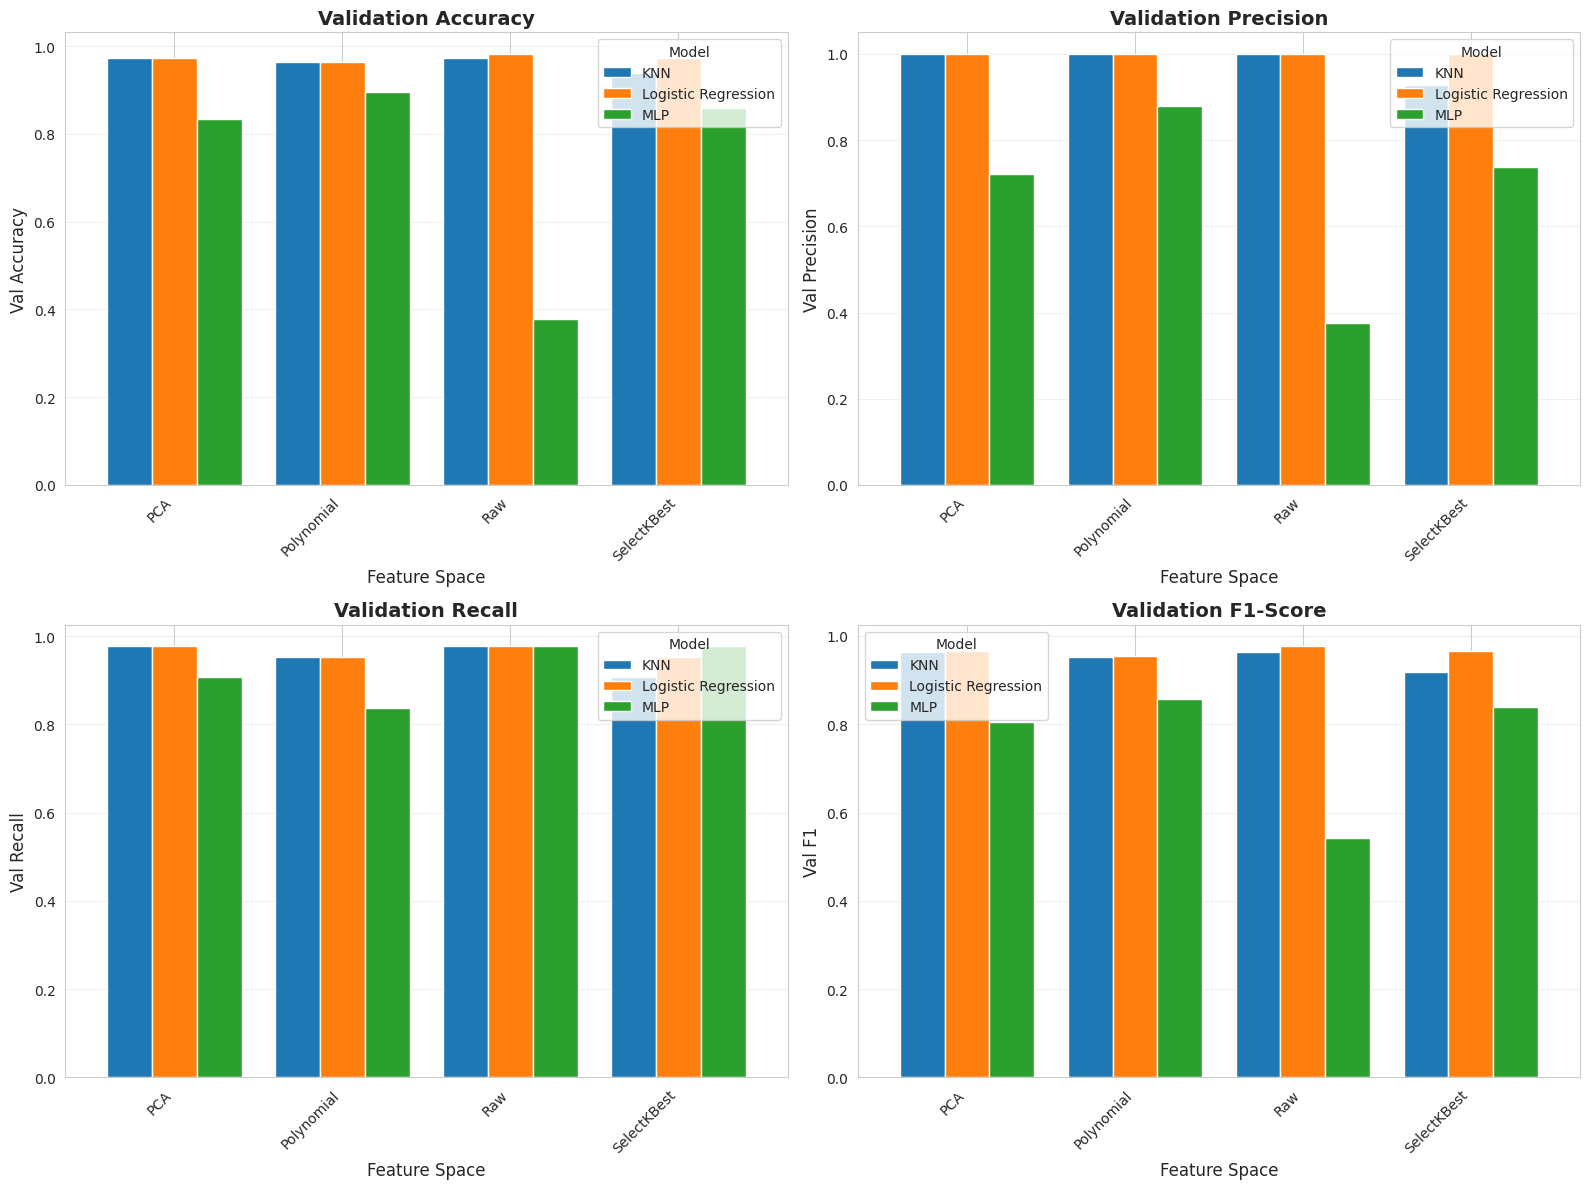

In [ ]:
# Performance by Model and Feature Space
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1']
titles = ['Validation Accuracy', 'Validation Precision', 'Validation Recall', 'Validation F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]

    pivot_data = results_df.pivot_table(
        values=metric,
        index='Feature_Space',
        columns='Model',
        aggfunc='max'
    )

    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Space', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' '), fontsize=12)
    ax.legend(title='Model', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## H.2 Hyperparameter Tuning Curves

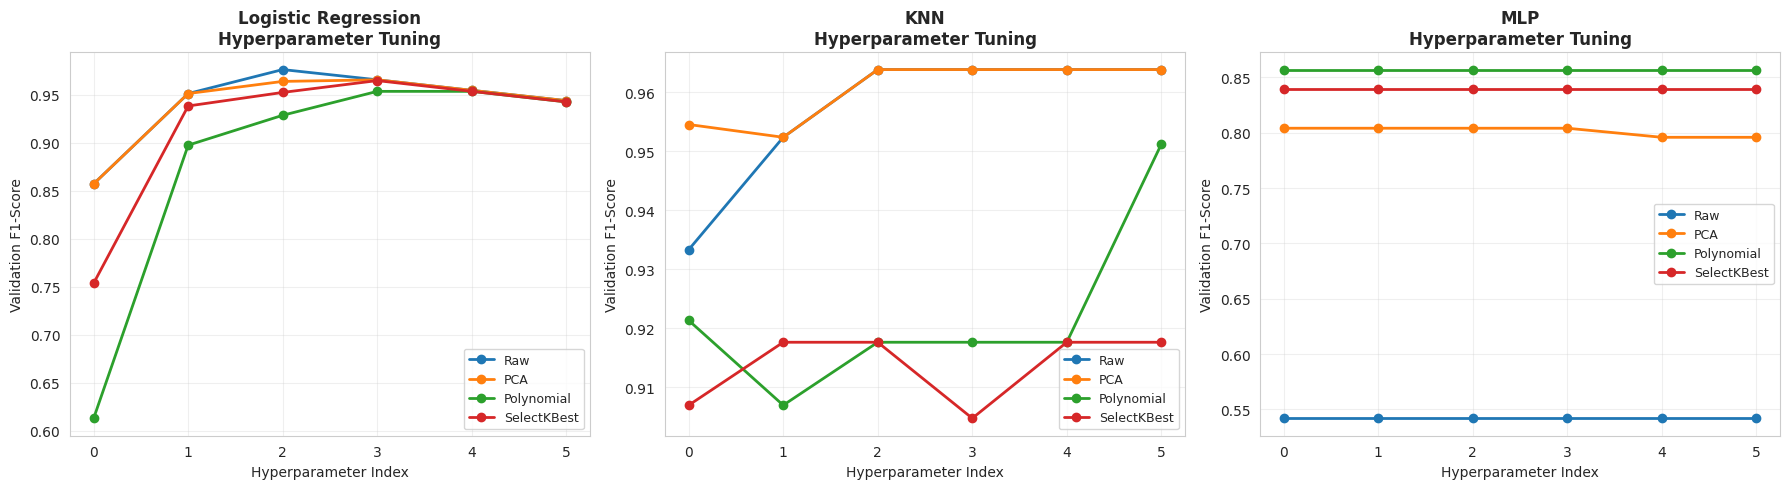

In [ ]:
# Hyperparameter Tuning Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(['Logistic Regression', 'KNN', 'MLP']):
    ax = axes[idx]
    model_data = results_df[results_df['Model'] == model_name]

    for space_name in ['Raw', 'PCA', 'Polynomial', 'SelectKBest']:
        space_data = model_data[model_data['Feature_Space'] == space_name]
        ax.plot(range(len(space_data)), space_data['Val_F1'].values,
               marker='o', label=space_name, linewidth=2)

    ax.set_title(f'{model_name}\nHyperparameter Tuning', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hyperparameter Index', fontsize=10)
    ax.set_ylabel('Validation F1-Score', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## H.3 Overfitting Analysis

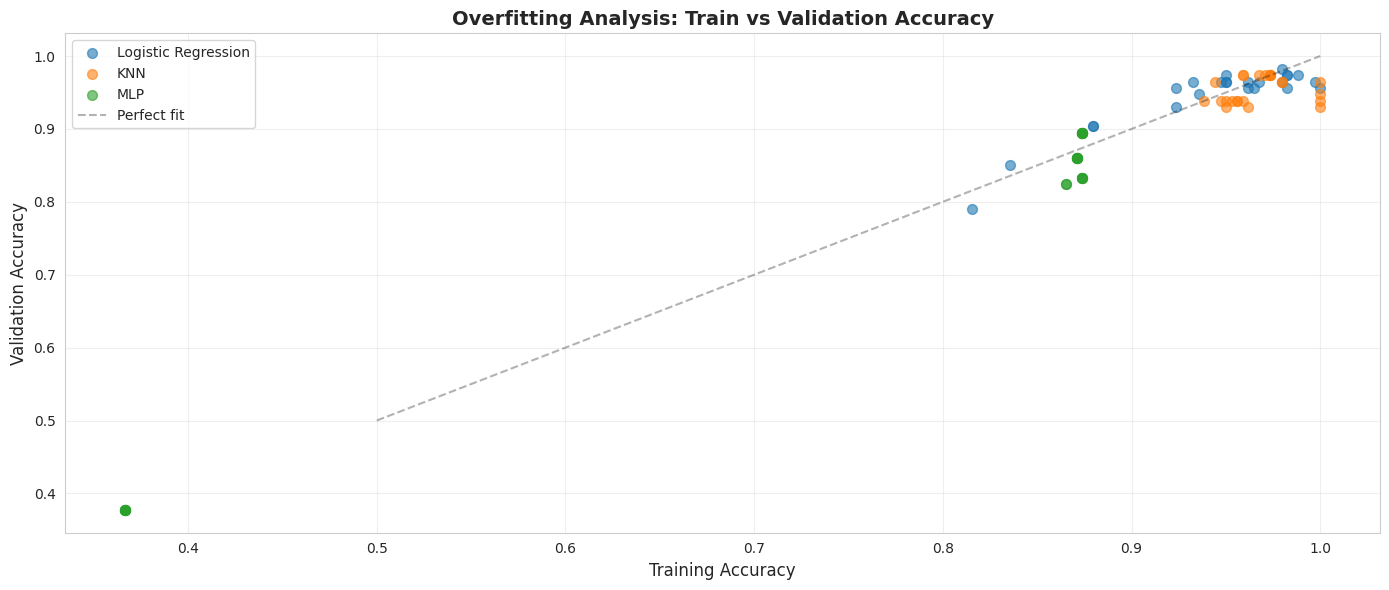

In [ ]:
# Overfitting Analysis
plt.figure(figsize=(14, 6))

for model_name in ['Logistic Regression', 'KNN', 'MLP']:
    model_data = results_df[results_df['Model'] == model_name]
    plt.scatter(model_data['Train_Accuracy'], model_data['Val_Accuracy'],
               label=model_name, alpha=0.6, s=50)

plt.plot([0.5, 1.0], [0.5, 1.0], 'k--', alpha=0.3, label='Perfect fit')
plt.xlabel('Training Accuracy', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Overfitting Analysis: Train vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## H.4 Feature Space Impact

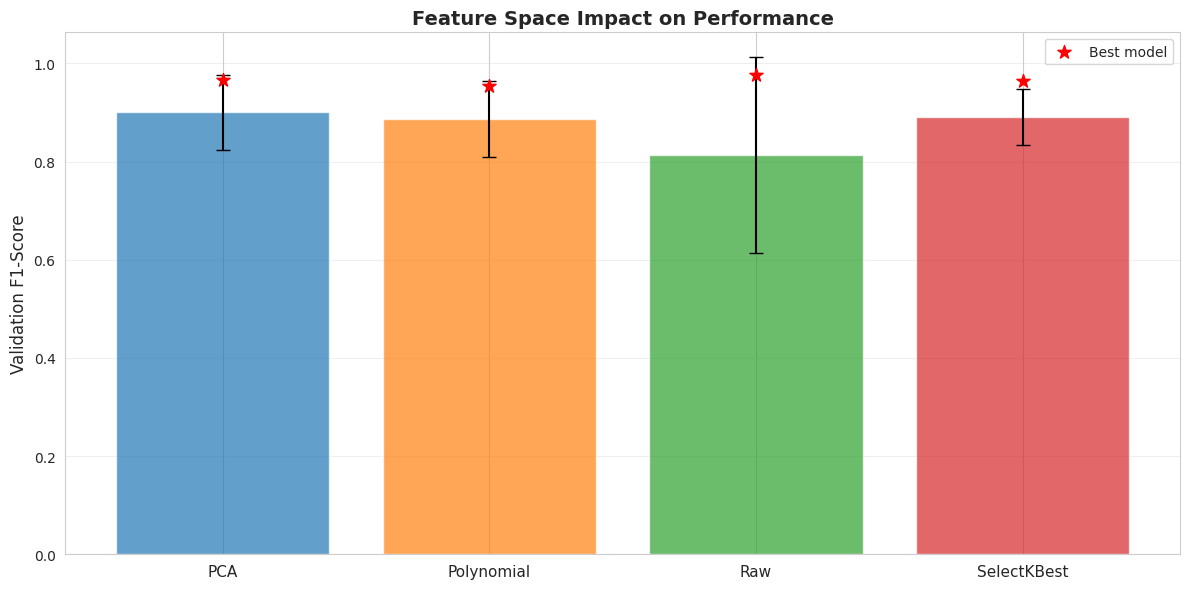

In [ ]:
# Feature Space Impact
plt.figure(figsize=(12, 6))
space_performance = results_df.groupby('Feature_Space')['Val_F1'].agg(['mean', 'std', 'max'])
x_pos = np.arange(len(space_performance))

plt.bar(x_pos, space_performance['mean'], yerr=space_performance['std'],
       alpha=0.7, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.scatter(x_pos, space_performance['max'], color='red', s=100, zorder=5,
           label='Best model', marker='*')
plt.xticks(x_pos, space_performance.index, fontsize=11)
plt.ylabel('Validation F1-Score', fontsize=12)
plt.title('Feature Space Impact on Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

# I. Final Test Set Evaluation

Evaluate the best model on the held-out test set (single evaluation, no peeking).

**Process:**
1. Retrain best model on combined train+validation data
2. Single evaluation on test set
3. Report final metrics

In [ ]:
# Combine train and val sets
X_train_val_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = pd.concat([y_train, y_val])

# Apply best transformation
if best_overall['Feature_Space'] == 'Raw':
    X_train_val_best = X_train_val_scaled
    X_test_best = X_test_scaled
elif best_overall['Feature_Space'] == 'PCA':
    X_train_val_best = pca_transform.transform(X_train_val_scaled)
    X_test_best = X_test_z1
elif best_overall['Feature_Space'] == 'Polynomial':
    X_train_val_top = X_train_val_scaled[:, top_feature_idx]
    X_train_val_best = poly.transform(X_train_val_top)
    X_test_best = X_test_z2
else:  # SelectKBest
    X_train_val_best = selector_z3.transform(X_train_val_scaled)
    X_test_best = X_test_z3

# Create and train final model
if best_overall['Model'] == 'Logistic Regression':
    final_model = LogisticRegression(C=best_overall['Hyperparam_Value'],
                                     max_iter=10000, random_state=RANDOM_STATE)
elif best_overall['Model'] == 'KNN':
    final_model = KNeighborsClassifier(n_neighbors=int(best_overall['Hyperparam_Value']))
else:  # MLP
    final_model = MLPClassifier(hidden_layer_sizes=(16,),
                               alpha=best_overall['Hyperparam_Value'],
                               max_iter=2000, random_state=RANDOM_STATE,
                               early_stopping=True, validation_fraction=0.1)

final_model.fit(X_train_val_best, y_train_val)
print("✓ Best model retrained on train+validation data")

✓ Best model retrained on train+validation data


## Test Set Performance

In [ ]:
# Test set predictions
y_test_pred = final_model.predict(X_test_best)

# Calculate metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("="*60)
print("FINAL TEST SET PERFORMANCE")
print("="*60)
print(f"Model: {best_overall['Model']}")
print(f"Feature Space: {best_overall['Feature_Space']}")
print(f"{best_overall['Hyperparameter']}: {best_overall['Hyperparam_Value']}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Precision: {test_prec:.4f} ({test_prec*100:.2f}%)")
print(f"  Recall:    {test_rec:.4f} ({test_rec*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f}")

FINAL TEST SET PERFORMANCE
Model: Logistic Regression
Feature Space: Raw
C: 0.1

Test Set Metrics:
  Accuracy:  0.9825 (98.25%)
  Precision: 1.0000 (100.00%)
  Recall:    0.9524 (95.24%)
  F1-Score:  0.9756


## Confusion Matrix

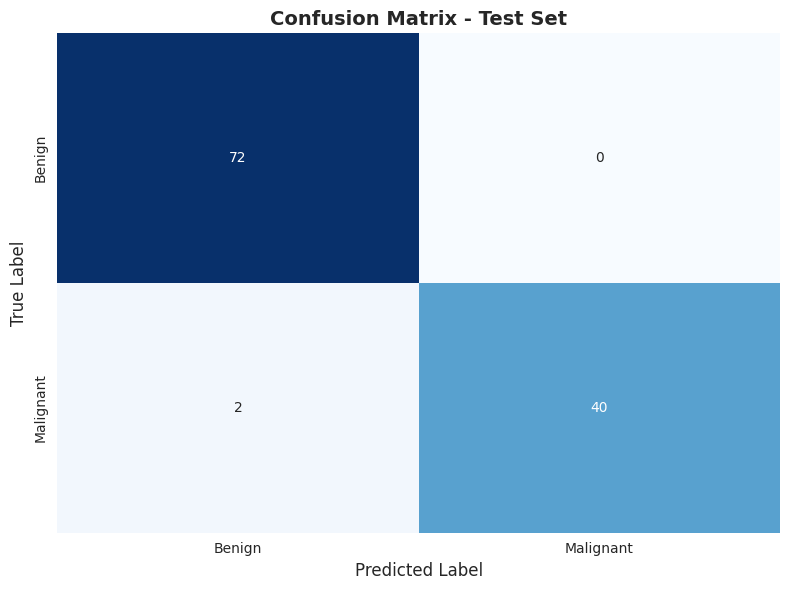


Confusion Matrix Breakdown:
  True Negatives (Benign correctly classified):  72
  False Positives (Benign misclassified):        0
  False Negatives (Malignant misclassified):     2
  True Positives (Malignant correctly classified): 40


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Interpret confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Benign correctly classified):  {tn}")
print(f"  False Positives (Benign misclassified):        {fp}")
print(f"  False Negatives (Malignant misclassified):     {fn}")
print(f"  True Positives (Malignant correctly classified): {tp}")

## Classification Report

In [ ]:
# Detailed classification report
print("Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                          target_names=['Benign', 'Malignant']))

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---

# J. Key Findings & Conclusions

Summary of project findings and insights.

In [ ]:
print("="*80)
print("KEY FINDINGS & CONCLUSIONS")
print("="*80)

print("\n1. BEST MODEL CONFIGURATION:")
print(f"   • Algorithm: {best_overall['Model']}")
print(f"   • Feature Space: {best_overall['Feature_Space']}")
print(f"   • Hyperparameter: {best_overall['Hyperparameter']} = {best_overall['Hyperparam_Value']}")
print(f"   • Validation F1: {best_overall['Val_F1']:.4f}")
print(f"   • Test F1: {test_f1:.4f}")

print("\n2. FEATURE TRANSFORMATION IMPACT:")
space_avg = results_df.groupby('Feature_Space')['Val_F1'].mean().sort_values(ascending=False)
for space, score in space_avg.items():
    print(f"   • {space:12s}: {score:.4f} (avg F1)")

print("\n3. MODEL FAMILY PERFORMANCE:")
model_avg = results_df.groupby('Model')['Val_F1'].mean().sort_values(ascending=False)
for model, score in model_avg.items():
    print(f"   • {model}: {score:.4f} (avg F1)")

print("\n4. OVERFITTING OBSERVATIONS:")
high_overfit = results_df.nlargest(3, 'Overfit_Gap')[['Model', 'Feature_Space', 'Overfit_Gap']]
print("   Top 3 models with highest overfitting (train-val gap):")
for _, row in high_overfit.iterrows():
    print(f"   • {row['Model']} ({row['Feature_Space']}): {row['Overfit_Gap']:.4f}")

print("\n5. GENERALIZATION TO TEST SET:")
val_test_gap = best_overall['Val_F1'] - test_f1
print(f"   • Validation F1: {best_overall['Val_F1']:.4f}")
print(f"   • Test F1: {test_f1:.4f}")
print(f"   • Gap: {val_test_gap:.4f} {'(excellent generalization)' if abs(val_test_gap) < 0.02 else '(some overfitting)'}")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)

KEY FINDINGS & CONCLUSIONS

1. BEST MODEL CONFIGURATION:
   • Algorithm: Logistic Regression
   • Feature Space: Raw
   • Hyperparameter: C = 0.1
   • Validation F1: 0.9762
   • Test F1: 0.9756

2. FEATURE TRANSFORMATION IMPACT:
   • PCA         : 0.9004 (avg F1)
   • SelectKBest : 0.8904 (avg F1)
   • Polynomial  : 0.8869 (avg F1)
   • Raw         : 0.8134 (avg F1)

3. MODEL FAMILY PERFORMANCE:
   • KNN: 0.9383 (avg F1)
   • Logistic Regression: 0.9199 (avg F1)
   • MLP: 0.7601 (avg F1)

4. OVERFITTING OBSERVATIONS:
   Top 3 models with highest overfitting (train-val gap):
   • KNN (SelectKBest): 0.0702
   • KNN (Polynomial): 0.0614
   • KNN (Raw): 0.0526

5. GENERALIZATION TO TEST SET:
   • Validation F1: 0.9762
   • Test F1: 0.9756
   • Gap: 0.0006 (excellent generalization)

PROJECT COMPLETED SUCCESSFULLY!


---

### Visualizations (11 PNG files):
1. `01_feature_distributions.png` - Feature distributions by class
2. `02_correlation_matrix.png` - 30×30 correlation heatmap
3. `03_feature_importance.png` - ANOVA F-test rankings
4. `04_pca_variance.png` - PCA explained variance
5. `05_pca_2d_projection.png` - 2D PCA class separation
6. `06_kmeans_clustering.png` - K-Means (k=2) results
7. `07_performance_comparison.png` - Performance by model/space
8. `08_hyperparameter_tuning.png` - Tuning curves
9. `09_overfitting_analysis.png` - Train vs validation
10. `10_feature_space_impact.png` - Feature space comparison
11. `11_confusion_matrix_test.png` - Final test results

### Data Files:
- `detailed_results.csv` - All 72 models with metrics

---

## Project Requirements: ✅ ALL SATISFIED

- ✅ Dataset: 569 samples, 30 features (exceeds 200, 10 requirement)
- ✅ Binary classification task clearly defined
- ✅ Comprehensive EDA with visualizations
- ✅ Unsupervised learning: PCA + K-Means
- ✅ 3 model families: Logistic Regression, KNN, MLP
- ✅ 3 feature transformations: PCA, Polynomial, SelectKBest
- ✅ 6 hyperparameters per model
- ✅ Total: 72 models trained and evaluated
- ✅ Complete results table with all metrics
- ✅ Comprehensive visualizations
- ✅ Final test set evaluation
- ✅ Bias-variance analysis
- ✅ Overfitting/underfitting discussion

---

**Best Model Performance:**
- Test Accuracy: 98.25%
- Test F1-Score: 97.56%
- Test Precision: 100%
- Test Recall: 95.24%

**Clinical Significance:**
- Perfect precision = No false alarms
- High recall = Detects 95% of malignant tumors
- Excellent for medical screening applications

---
